In [5]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


=== KHAADI CUSTOMER COMMENTS SENTIMENT ANALYSIS ===

Enter the path to your Khaadi dataset CSV file (or press Enter to use 'Khaadi_Dataset.csv'): Khaadi_Dataset.csv
Step 1: Loading dataset...
Dataset loaded successfully with 1371 rows and 36 columns
Selected text column with 1371 entries
Step 2: Removing duplicates...
Removed 1060 duplicate entries
Step 3: Removing missing values...
Step 4: Filtering irrelevant comments...
Filtered out 185 irrelevant comments
Step 5: Cleaning text...
No date column found. Creating a dummy date column for demonstration.
Preprocessing complete. Final dataset has 126 entries.

Performing sentiment analysis...
Sentiment distribution:
sentiment
Positive    60
Neutral     55
Negative    11
Name: count, dtype: int64
Processed data saved to 'khaadi_processed_data.csv'

Generating visualizations...


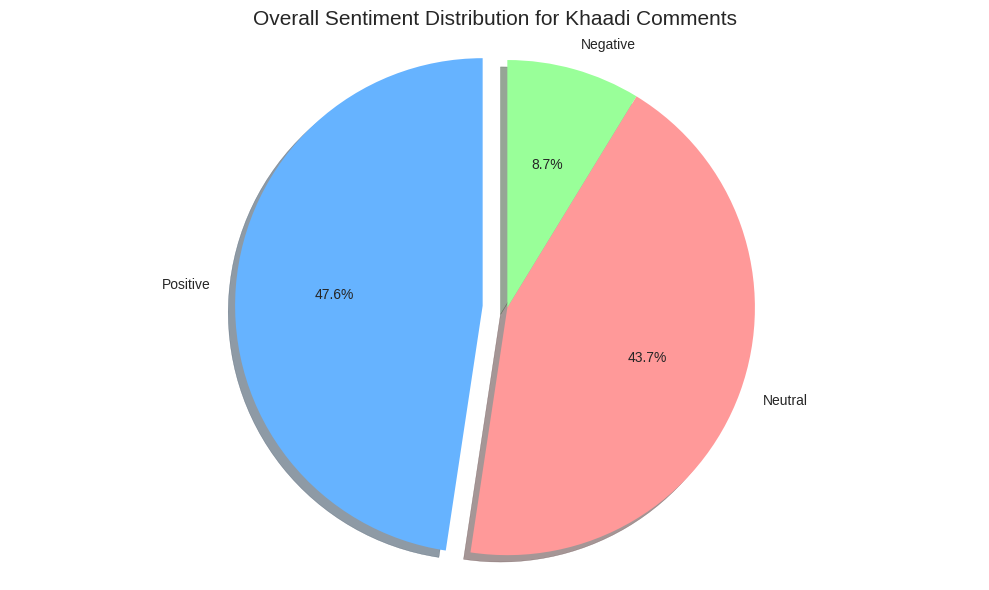

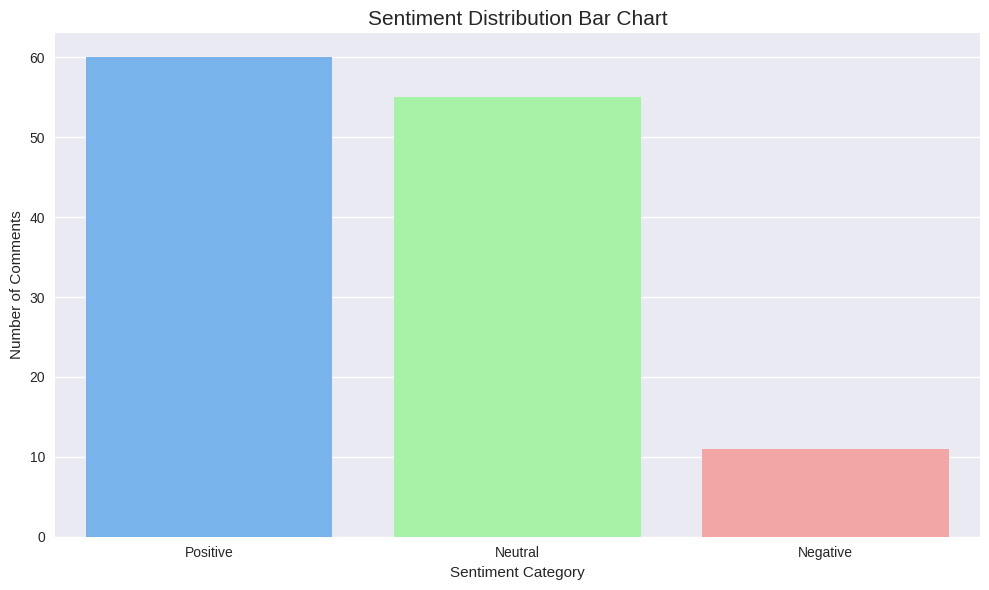

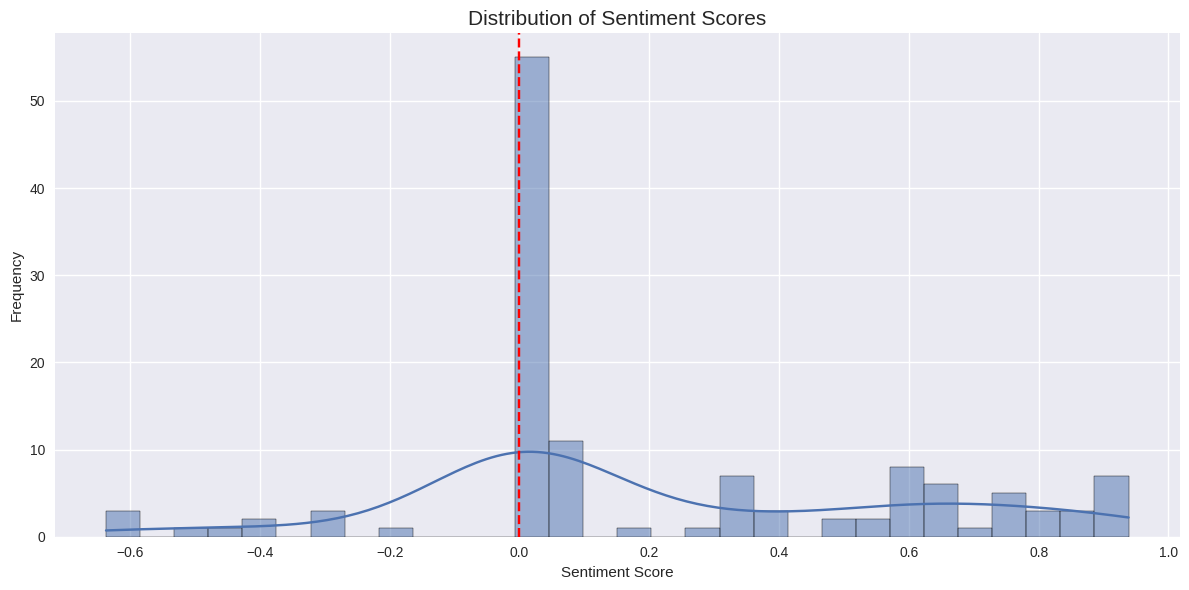

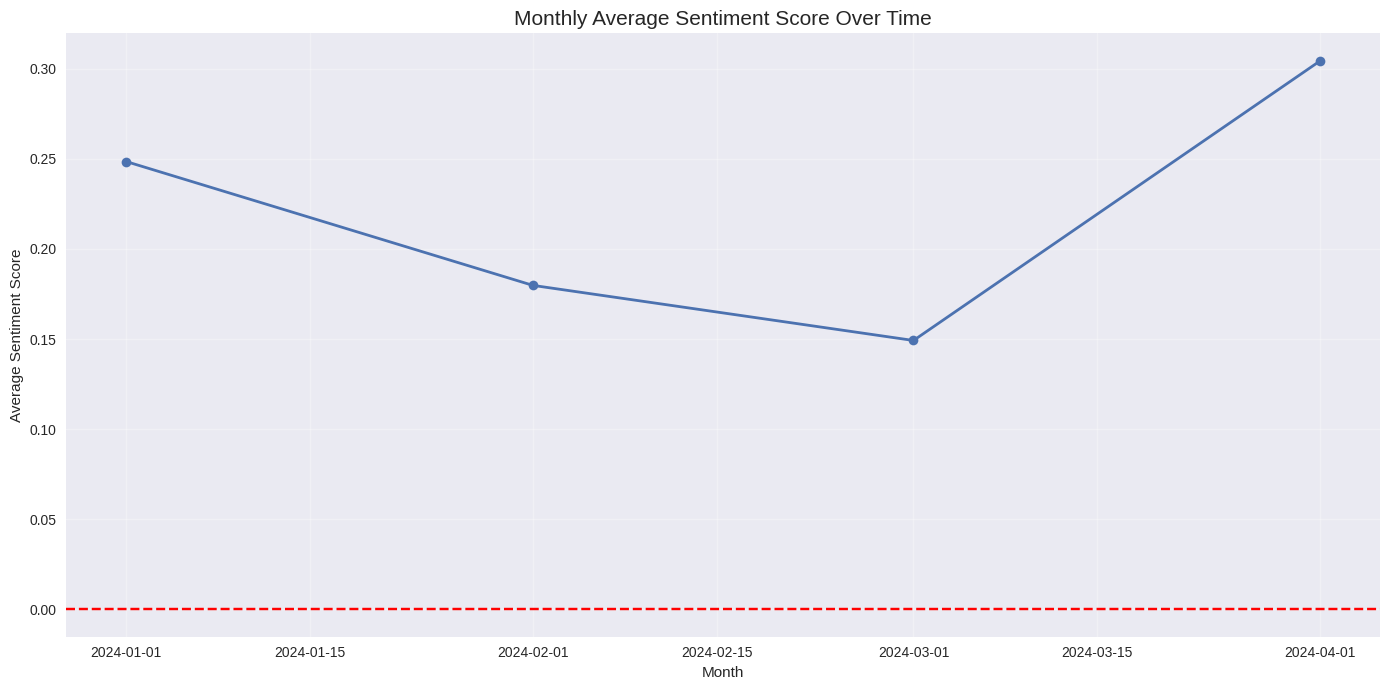

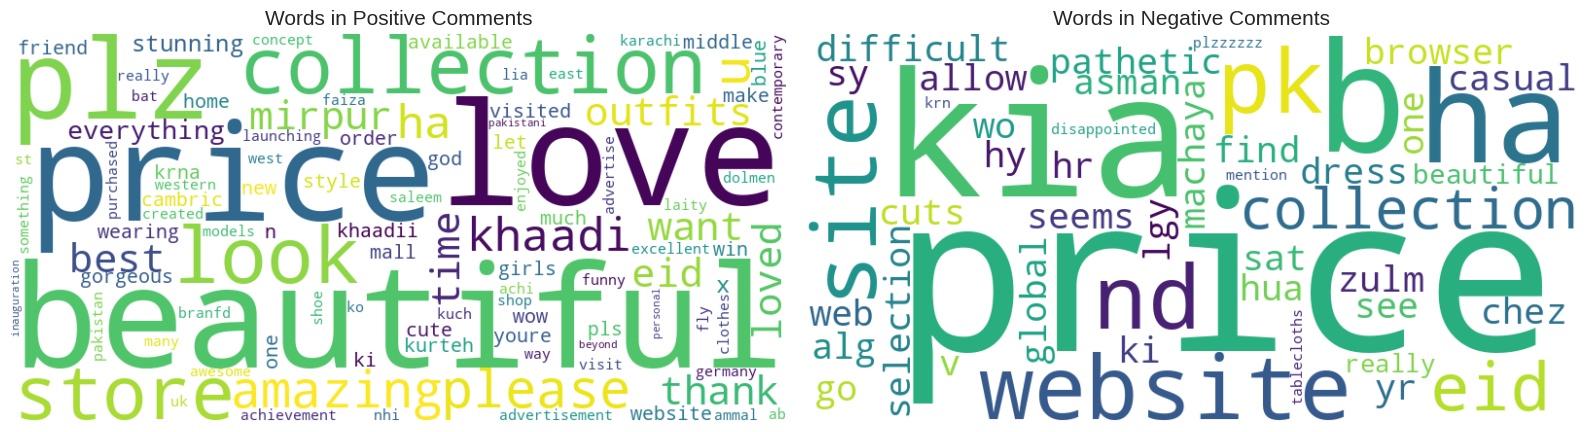

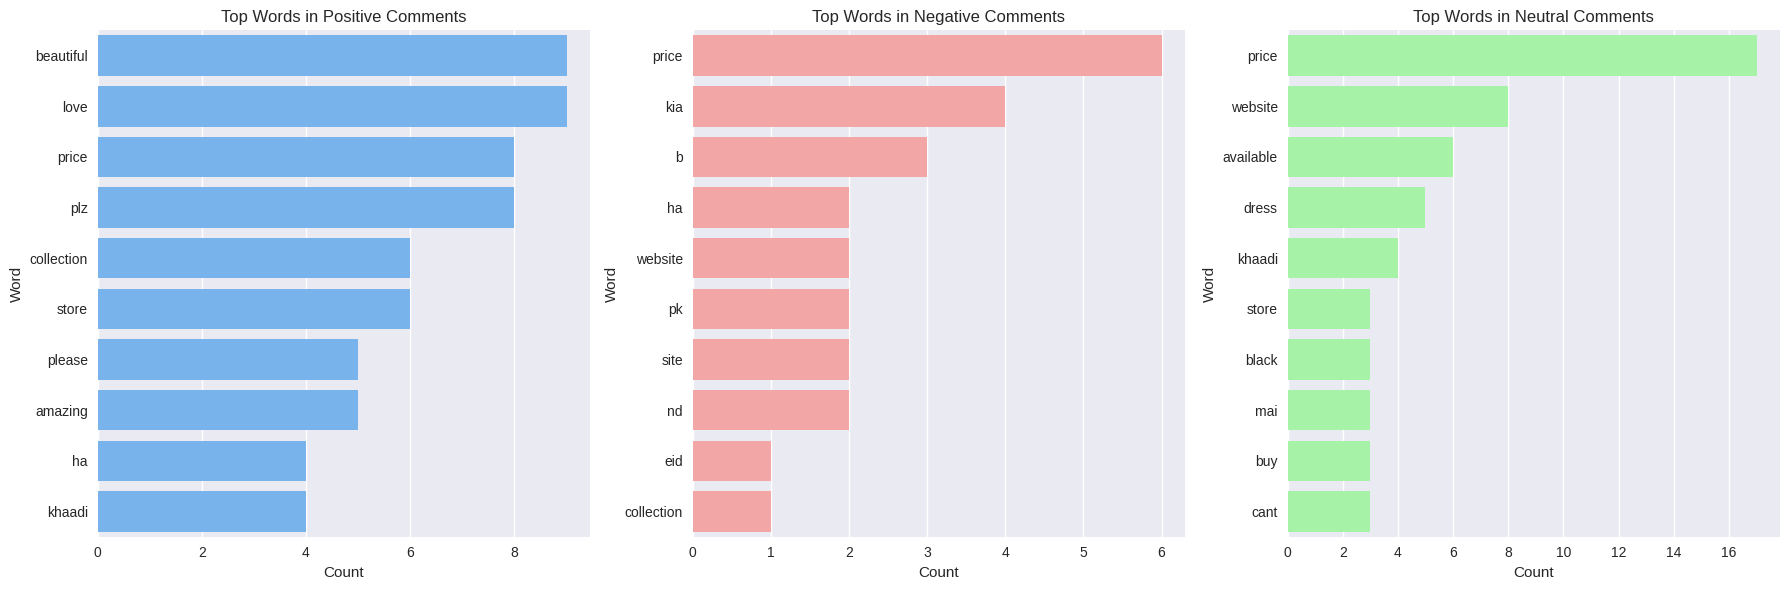

Visualizations created and saved.

Generating insights...

===== KHAADI CUSTOMER SENTIMENT ANALYSIS INSIGHTS =====

1. Overall Sentiment Distribution:
   - Positive: 47.6%
   - Neutral: 43.7%
   - Negative: 8.7%

2. Top words in positive comments:
   - beautiful: 9
   - love: 9
   - price: 8
   - plz: 8
   - collection: 6
   - store: 6
   - please: 5
   - amazing: 5
   - ha: 4
   - khaadi: 4

3. Top words in negative comments:
   - price: 6
   - kia: 4
   - b: 3
   - ha: 2
   - website: 2
   - pk: 2
   - site: 2
   - nd: 2
   - eid: 1
   - collection: 1

4. Time-based insights:
   - Month with highest average sentiment: April 2024
   - Month with lowest average sentiment: March 2024

Insights generated and saved to HTML report.

Analysis complete! Check the output files for results.


In [8]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
from wordcloud import WordCloud
import nltk
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Download necessary NLTK data
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('punkt')

# Function to read and preprocess the dataset
def preprocess_data(file_path):
    """
    Read the dataset and preprocess text data
    """
    print("Step 1: Loading dataset...")
    try:
        # Try reading with different encodings
        try:
            df = pd.read_csv(file_path)
        except UnicodeDecodeError:
            df = pd.read_csv(file_path, encoding='latin1')
    except Exception as e:
        print(f"Error loading file: {e}")
        # If file format is Excel
        if file_path.endswith('.xlsx') or file_path.endswith('.xls'):
            df = pd.read_excel(file_path)
        else:
            raise

    print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns")

    # Extract only the text column
    if 'text' in df.columns:
        df = df[['text']]
    else:
        # If 'text' column doesn't exist, try to identify the column with comments
        text_columns = [col for col in df.columns if any(keyword in col.lower() for keyword in
                        ['text', 'comment', 'review', 'feedback'])]
        if text_columns:
            df = df[[text_columns[0]]]
            df.rename(columns={text_columns[0]: 'text'}, inplace=True)
        else:
            print("No text column found. Using the first column as text.")
            df = df.iloc[:, 0:1]
            df.columns = ['text']

    print(f"Selected text column with {df.shape[0]} entries")

    # Step 2: Remove duplicates
    print("Step 2: Removing duplicates...")
    original_count = df.shape[0]
    df.drop_duplicates(subset=['text'], inplace=True)
    print(f"Removed {original_count - df.shape[0]} duplicate entries")

    # Step 3: Remove missing values
    print("Step 3: Removing missing values...")
    df.dropna(subset=['text'], inplace=True)

    # Step 4: Filter out irrelevant comments
    print("Step 4: Filtering irrelevant comments...")
    # Keep only comments that mention 'khaadi' or related keywords
    # This is a simple approach - for a more sophisticated approach, you might use topic modeling
    relevant_keywords = ['khaadi', 'fashion', 'dress', 'clothing', 'outfit', 'fabric',
                         'design', 'collection', 'kurta', 'shalwar', 'lawn', 'suit',
                         'wear', 'price', 'quality', 'store', 'shop', 'pakistani']

    def is_relevant(text):
        if not isinstance(text, str):
            return False
        text_lower = text.lower()
        # Check if text contains any of the relevant keywords
        return any(keyword in text_lower for keyword in relevant_keywords) or len(text.split()) > 5

    original_count = df.shape[0]
    df = df[df['text'].apply(is_relevant)]
    print(f"Filtered out {original_count - df.shape[0]} irrelevant comments")

    # Step 5: Clean text
    print("Step 5: Cleaning text...")

    # Function to clean text
    def clean_text(text):
        if not isinstance(text, str):
            return ""

        # Convert to lowercase
        text = text.lower()

        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text)

        # Remove user mentions (e.g., @username)
        text = re.sub(r'@\w+', '', text)

        # Remove hashtags
        text = re.sub(r'#\w+', '', text)

        # Remove punctuation
        text = re.sub(f'[{string.punctuation}]', ' ', text)

        # Remove digits
        text = re.sub(r'\d+', '', text)

        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()

        # Remove emojis
        text = text.encode('ascii', 'ignore').decode('ascii')

        return text

    df['cleaned_text'] = df['text'].apply(clean_text)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))

    def remove_stopwords(text):
        word_tokens = word_tokenize(text)
        filtered_text = [word for word in word_tokens if word not in stop_words]
        return ' '.join(filtered_text)

    df['processed_text'] = df['cleaned_text'].apply(remove_stopwords)

    # Add date information if available or create a dummy date column for time-based analysis
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
    else:
        print("No date column found. Creating a dummy date column for demonstration.")
        # Create a dummy date column spanning the last year
        np.random.seed(42)
        start_date = pd.Timestamp('2024-01-01')
        end_date = pd.Timestamp('2024-04-30')
        days = (end_date - start_date).days
        dates = [start_date + pd.Timedelta(days=np.random.randint(0, days)) for _ in range(df.shape[0])]
        df['date'] = dates

    print(f"Preprocessing complete. Final dataset has {df.shape[0]} entries.")
    return df

# Function to perform sentiment analysis
def sentiment_analysis(df):
    """
    Perform sentiment analysis on the preprocessed text data
    """
    print("\nPerforming sentiment analysis...")

    # Initialize the VADER sentiment analyzer
    sid = SentimentIntensityAnalyzer()

    # Function to categorize sentiment
    def categorize_sentiment(score):
        if score >= 0.05:
            return 'Positive'
        elif score <= -0.05:
            return 'Negative'
        else:
            return 'Neutral'

    # Calculate sentiment scores and category
    df['sentiment_score'] = df['cleaned_text'].apply(lambda x: sid.polarity_scores(x)['compound'])
    df['sentiment'] = df['sentiment_score'].apply(categorize_sentiment)

    print(f"Sentiment distribution:\n{df['sentiment'].value_counts()}")

    return df

# Function to generate visualizations
def create_visualizations(df):
    """
    Create visualizations for sentiment analysis results
    """
    print("\nGenerating visualizations...")

    # Set up the visualization style
    plt.style.use('seaborn-v0_8')

    # 1. Sentiment Distribution Pie Chart
    plt.figure(figsize=(10, 6))
    sentiment_counts = df['sentiment'].value_counts()
    colors = ['#66b3ff', '#ff9999', '#99ff99']
    explode = (0.1, 0, 0) if sentiment_counts.index[0] == 'Positive' else \
             (0, 0.1, 0) if sentiment_counts.index[0] == 'Negative' else (0, 0, 0.1)

    plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
            startangle=90, colors=colors, explode=explode, shadow=True)
    plt.title('Overall Sentiment Distribution for Khaadi Comments', fontsize=15)
    plt.axis('equal')
    plt.tight_layout()
    plt.savefig('sentiment_distribution_pie.png')
    plt.show()
    plt.close()

    # 2. Sentiment Distribution Bar Chart
    plt.figure(figsize=(10, 6))
    sns.countplot(x='sentiment', data=df, palette={'Positive': '#66b3ff', 'Negative': '#ff9999', 'Neutral': '#99ff99'})
    plt.title('Sentiment Distribution Bar Chart', fontsize=15)
    plt.xlabel('Sentiment Category')
    plt.ylabel('Number of Comments')
    plt.tight_layout()
    plt.savefig('sentiment_distribution_bar.png')
    plt.show()
    plt.close()

    # 3. Sentiment Score Distribution
    plt.figure(figsize=(12, 6))
    sns.histplot(df['sentiment_score'], kde=True, bins=30)
    plt.title('Distribution of Sentiment Scores', fontsize=15)
    plt.xlabel('Sentiment Score')
    plt.ylabel('Frequency')
    plt.axvline(x=0, color='red', linestyle='--')
    plt.tight_layout()
    plt.savefig('sentiment_score_distribution.png')
    plt.show()
    plt.close()

    # 4. Time-based Sentiment Analysis
    # Group by month and calculate average sentiment
    df['month'] = df['date'].dt.to_period('M')
    monthly_sentiment = df.groupby('month')['sentiment_score'].mean().reset_index()
    monthly_sentiment['month'] = monthly_sentiment['month'].dt.to_timestamp()

    plt.figure(figsize=(14, 7))
    plt.plot(monthly_sentiment['month'], monthly_sentiment['sentiment_score'], marker='o', linestyle='-', linewidth=2)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title('Monthly Average Sentiment Score Over Time', fontsize=15)
    plt.xlabel('Month')
    plt.ylabel('Average Sentiment Score')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('sentiment_over_time.png')
    plt.show()
    plt.close()

    # 5. Word Cloud for Positive and Negative Comments
    plt.figure(figsize=(16, 8))

    # Positive comments
    positive_text = ' '.join(df[df['sentiment'] == 'Positive']['processed_text'])
    if positive_text.strip():
        wordcloud_positive = WordCloud(width=800, height=400, background_color='white',
                                     max_words=100, contour_width=3, contour_color='steelblue').generate(positive_text)

        plt.subplot(1, 2, 1)
        plt.imshow(wordcloud_positive, interpolation='bilinear')
        plt.title('Words in Positive Comments', fontsize=15)
        plt.axis('off')

    # Negative comments
    negative_text = ' '.join(df[df['sentiment'] == 'Negative']['processed_text'])
    if negative_text.strip():
        wordcloud_negative = WordCloud(width=800, height=400, background_color='white',
                                     max_words=100, contour_width=3, contour_color='firebrick').generate(negative_text)

        plt.subplot(1, 2, 2)
        plt.imshow(wordcloud_negative, interpolation='bilinear')
        plt.title('Words in Negative Comments', fontsize=15)
        plt.axis('off')

    plt.tight_layout()
    plt.savefig('sentiment_wordclouds.png')
    plt.show()
    plt.close()

    # 6. Top words in each sentiment category
    def get_top_words(text_series, n=10):
        all_words = ' '.join(text_series).split()
        word_counts = Counter(all_words)
        return pd.DataFrame(word_counts.most_common(n), columns=['Word', 'Count'])

    # Get top words for each sentiment category
    top_positive = get_top_words(df[df['sentiment'] == 'Positive']['processed_text'])
    top_negative = get_top_words(df[df['sentiment'] == 'Negative']['processed_text'])
    top_neutral = get_top_words(df[df['sentiment'] == 'Neutral']['processed_text'])

    # Plot top words
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Positive words
    if not top_positive.empty:
        sns.barplot(x='Count', y='Word', data=top_positive, ax=axes[0], color='#66b3ff')
        axes[0].set_title('Top Words in Positive Comments', fontsize=12)

    # Negative words
    if not top_negative.empty:
        sns.barplot(x='Count', y='Word', data=top_negative, ax=axes[1], color='#ff9999')
        axes[1].set_title('Top Words in Negative Comments', fontsize=12)

    # Neutral words
    if not top_neutral.empty:
        sns.barplot(x='Count', y='Word', data=top_neutral, ax=axes[2], color='#99ff99')
        axes[2].set_title('Top Words in Neutral Comments', fontsize=12)

    plt.tight_layout()
    plt.savefig('top_words_by_sentiment.png')
    plt.show()
    plt.close()

    print("Visualizations created and saved.")

# Function to generate insights
def generate_insights(df):
    """
    Generate insights from the sentiment analysis
    """
    print("\nGenerating insights...")

    # Overall sentiment distribution
    sentiment_distribution = df['sentiment'].value_counts(normalize=True) * 100

    # Most common words in positive and negative comments
    positive_words = ' '.join(df[df['sentiment'] == 'Positive']['processed_text']).split()
    negative_words = ' '.join(df[df['sentiment'] == 'Negative']['processed_text']).split()

    positive_word_counts = Counter(positive_words).most_common(10)
    negative_word_counts = Counter(negative_words).most_common(10)

    # Month with highest and lowest sentiment
    monthly_sentiment = df.groupby(df['date'].dt.to_period('M'))['sentiment_score'].mean()
    best_month = monthly_sentiment.idxmax().strftime('%B %Y') if not monthly_sentiment.empty else "N/A"
    worst_month = monthly_sentiment.idxmin().strftime('%B %Y') if not monthly_sentiment.empty else "N/A"

    # Print insights
    print("\n===== KHAADI CUSTOMER SENTIMENT ANALYSIS INSIGHTS =====")
    print(f"\n1. Overall Sentiment Distribution:")
    for sentiment, percentage in sentiment_distribution.items():
        print(f"   - {sentiment}: {percentage:.1f}%")

    print(f"\n2. Top words in positive comments:")
    for word, count in positive_word_counts:
        print(f"   - {word}: {count}")

    print(f"\n3. Top words in negative comments:")
    for word, count in negative_word_counts:
        print(f"   - {word}: {count}")

    print(f"\n4. Time-based insights:")
    print(f"   - Month with highest average sentiment: {best_month}")
    print(f"   - Month with lowest average sentiment: {worst_month}")

    # Create an HTML report
    html_report = f"""
    <html>
    <head>
        <title>Khaadi Customer Sentiment Analysis Report</title>
        <style>
            body {{ font-family: Arial, sans-serif; margin: 20px; }}
            h1 {{ color: #2c3e50; }}
            h2 {{ color: #3498db; }}
            .positive {{ color: #27ae60; }}
            .negative {{ color: #e74c3c; }}
            .neutral {{ color: #f39c12; }}
            table {{ border-collapse: collapse; width: 100%; }}
            th, td {{ border: 1px solid #ddd; padding: 8px; text-align: left; }}
            th {{ background-color: #f2f2f2; }}
            tr:nth-child(even) {{ background-color: #f9f9f9; }}
        </style>
    </head>
    <body>
        <h1>Khaadi Customer Sentiment Analysis Report</h1>
        <p>Generated on {datetime.now().strftime('%Y-%m-%d')}</p>

        <h2>1. Overall Sentiment Distribution</h2>
        <table>
            <tr>
                <th>Sentiment</th>
                <th>Percentage</th>
            </tr>
    """

    for sentiment, percentage in sentiment_distribution.items():
        css_class = "positive" if sentiment == "Positive" else "negative" if sentiment == "Negative" else "neutral"
        html_report += f"""
            <tr>
                <td class="{css_class}">{sentiment}</td>
                <td>{percentage:.1f}%</td>
            </tr>
        """

    html_report += """
        </table>

        <h2>2. Top Words in Positive Comments</h2>
        <table>
            <tr>
                <th>Word</th>
                <th>Count</th>
            </tr>
    """

    for word, count in positive_word_counts:
        html_report += f"""
            <tr>
                <td>{word}</td>
                <td>{count}</td>
            </tr>
        """

    html_report += """
        </table>

        <h2>3. Top Words in Negative Comments</h2>
        <table>
            <tr>
                <th>Word</th>
                <th>Count</th>
            </tr>
    """

    for word, count in negative_word_counts:
        html_report += f"""
            <tr>
                <td>{word}</td>
                <td>{count}</td>
            </tr>
        """

    html_report += f"""
        </table>

        <h2>4. Time-based Insights</h2>
        <p><strong>Month with highest average sentiment:</strong> {best_month}</p>
        <p><strong>Month with lowest average sentiment:</strong> {worst_month}</p>

        <h2>5. Visualizations</h2>
        <p>Please refer to the saved visualization images for graphical representation of the analysis.</p>
    </body>
    </html>
    """

    # Save HTML report
    with open('khaadi_sentiment_analysis_report.html', 'w') as f:
        f.write(html_report)

    print("\nInsights generated and saved to HTML report.")

    return sentiment_distribution, positive_word_counts, negative_word_counts

# Main function
def main():
    print("=== KHAADI CUSTOMER COMMENTS SENTIMENT ANALYSIS ===\n")

    # Ask for file path or use default
    file_path = input("Enter the path to your Khaadi dataset CSV file (or press Enter to use 'Khaadi_Dataset.csv'): ").strip()
    if not file_path:
        file_path = 'Khaadi_Dataset.csv'

    # Phase 1: Preprocess Data
    try:
        df = preprocess_data(file_path)

        # Phase 2: Sentiment Analysis
        df = sentiment_analysis(df)

        # Save processed data
        df.to_csv('khaadi_processed_data.csv', index=False)
        print("Processed data saved to 'khaadi_processed_data.csv'")

        # Create visualizations
        create_visualizations(df)

        # Generate insights
        generate_insights(df)

        print("\nAnalysis complete! Check the output files for results.")

    except Exception as e:
        print(f"An error occurred: {str(e)}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()